In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from train_test_split import load_grouped_splits
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load premade splits
`python
data = tuple(X_train, y_train, X_val, y_val, X_test, y_test, class_names)

In [2]:
data = load_grouped_splits()
X_train, y_train, X_val, y_val, X_test, y_test, classes = data

# Concatenate training and validation sets to do CV on combined set
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))
print(X_train_val.shape)
print(X_train.shape)
print("Classes:")
print(data[-1])

Train size: 96
Validation size: 24
Test size: 32
(120, 16384)
(96, 16384)
Classes:
['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']


### Grid search for best Decision Tree Bagging (and PCA) hyperparameters

In [3]:
pipeline = Pipeline([
    ('pca', PCA()),
    ('classifier', BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42))
])

param_grid = {
    'pca__n_components': [0.90],
    'classifier__n_estimators': [100],
    'classifier__estimator__max_depth': [None],
    'classifier__estimator__min_samples_split': [5],
    'classifier__estimator__min_samples_leaf': [1],
    'classifier__max_samples': [1.0],
    'classifier__bootstrap': [True]
}


grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=2)

In [4]:
grid_search.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__bootstrap': [True], 'classifier__estimator__max_depth': [None], 'classifier__estimator__min_samples_leaf': [1], 'classifier__estimator__min_samples_split': [5], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,0.9


In [5]:
X_train_val_pred = grid_search.best_estimator_.predict(X_train_val)
train_accuracy = accuracy_score(y_train_val, X_train_val_pred)
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Val Accuracy with best parameters: {grid_search.best_score_}")

Best parameters found: {'classifier__bootstrap': True, 'classifier__estimator__max_depth': None, 'classifier__estimator__min_samples_leaf': 1, 'classifier__estimator__min_samples_split': 5, 'classifier__max_samples': 1.0, 'classifier__n_estimators': 100, 'pca__n_components': 0.9}
Val Accuracy with best parameters: 0.33333333333333337


Test Accuracy: 0.40625
Classification Report:
              precision    recall  f1-score   support

       Anger       0.40      0.50      0.44         4
    Contempt       0.00      0.00      0.00         4
     Disgust       0.67      0.50      0.57         4
        Fear       0.50      0.50      0.50         4
       Happy       0.80      1.00      0.89         4
     Neutral       0.33      0.50      0.40         4
         Sad       0.00      0.00      0.00         4
   Surprised       0.50      0.25      0.33         4

    accuracy                           0.41        32
   macro avg       0.40      0.41      0.39        32
weighted avg       0.40      0.41      0.39        32

Confusion Matrix:


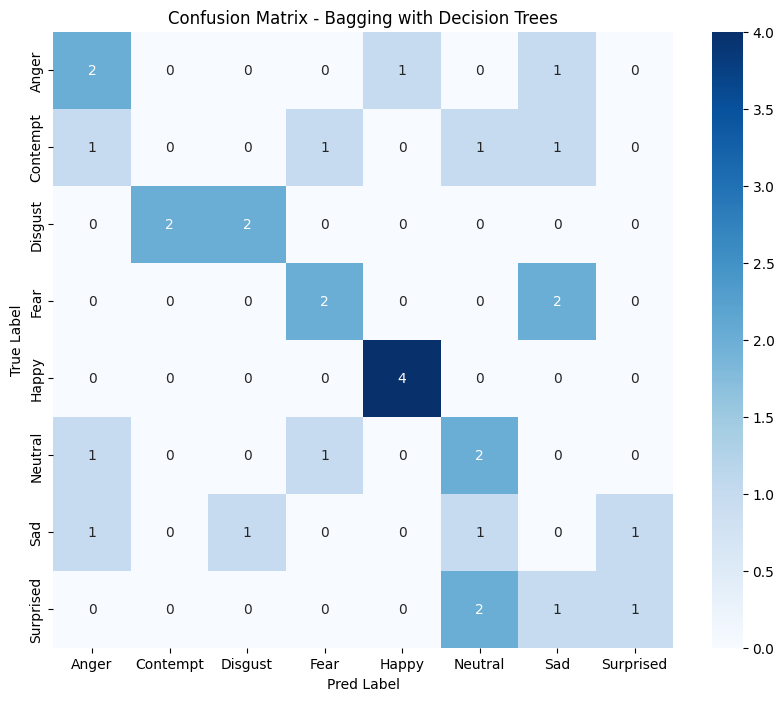

In [7]:
y_test_pred = grid_search.best_estimator_.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=classes))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Bagging with Decision Trees')
plt.xlabel('Pred Label')
plt.ylabel('True Label')
plt.show()

In [7]:
rf_test = RandomForestClassifier(n_estimators=200, random_state=42)
pca_test = PCA(n_components=0.95)
X_train_val_pca = pca_test.fit_transform(X_train_val)
X_test_pca = pca_test.transform(X_test)
rf_test.fit(X_train_val_pca, y_train_val)
y_test_pred_simple = rf_test.predict(X_test_pca)
simple_test_accuracy = accuracy_score(y_test, y_test_pred_simple)
print(f"Test Accuracy with simple Random Forest and PCA: {simple_test_accuracy}")


Test Accuracy with simple Random Forest and PCA: 0.4375
